## 数据增强
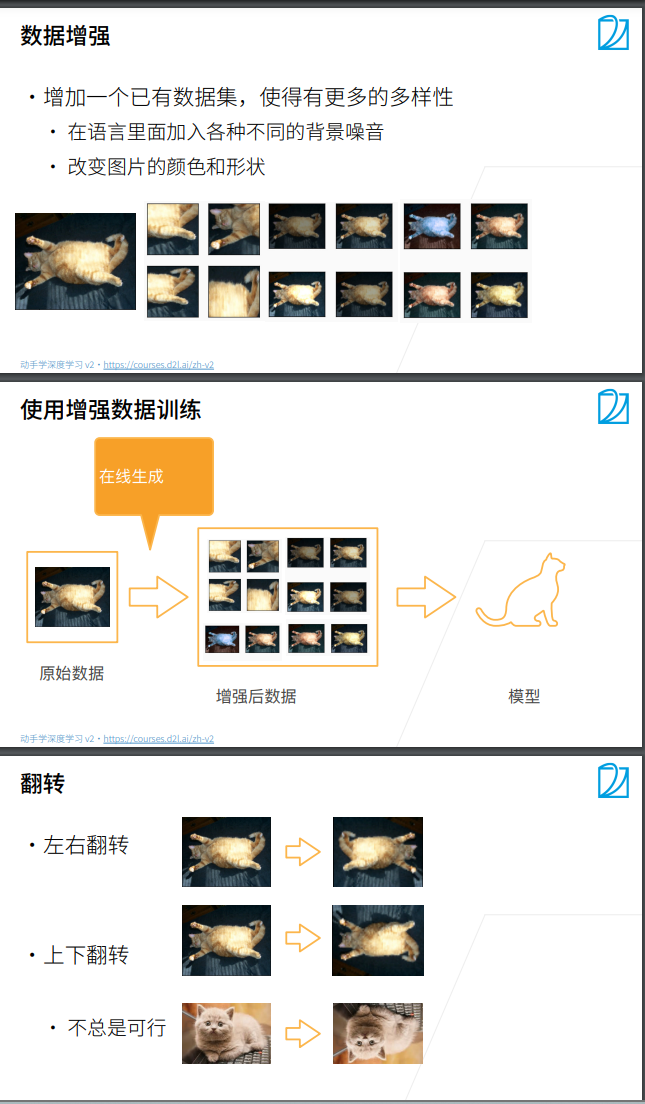
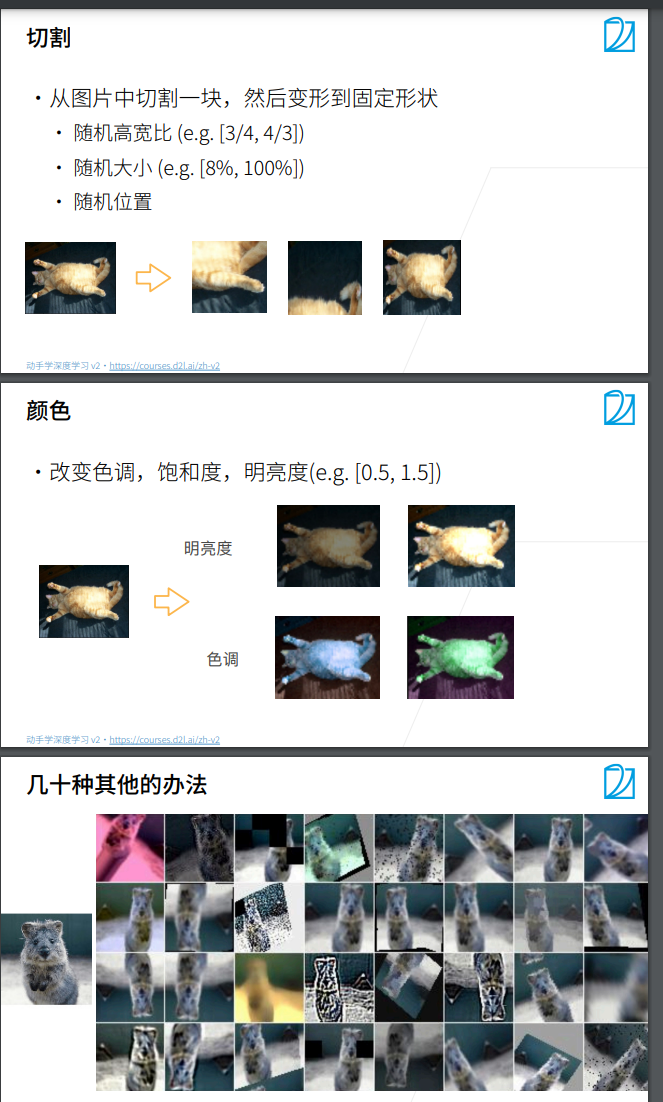
增广的目的是让训练集的分布更像测试集，增加模型的泛化性。增广能增加训练集的多样性，指均值不太变，方差变大

对于图片：翻转、截取、色温色调明亮度、去除一部分像素（ps能干的都算增广）。还可以多张图片拼接在一起，同时label也拼接的增广方式，详见yolov5的mosaic。还有mixup的增广，见下图。独热变量各自乘以权重相加，同时图片也乘以权重直接加起来
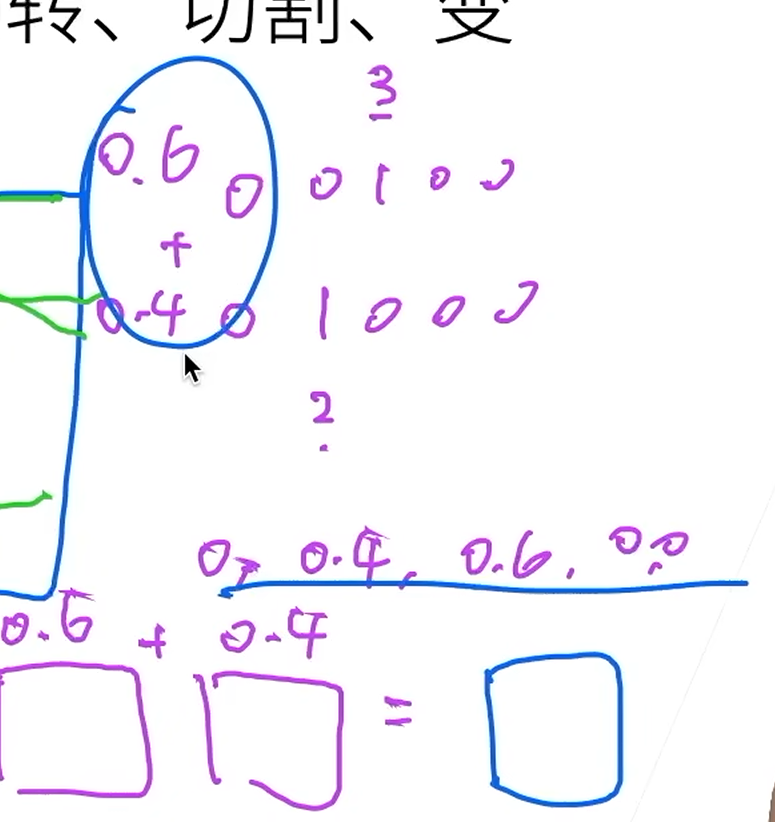

有些图片不能够上下颠倒的，比如建筑，违反重力的。

对于语音：加噪音

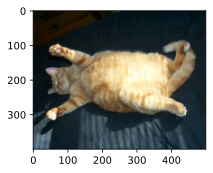

In [1]:
%matplotlib inline
import torch
from d2l import torch as d2l
import torchvision
from torch import nn

d2l.set_figsize()
img = d2l.Image.open('../data/img/cat1.jpg')
d2l.plt.imshow(img)

In [8]:
def apply(img, aug, num_rows=2, num_cols=4, scale=1.5):
    Y = [aug(img) for _ in range(num_rows*num_cols)]
    d2l.show_images(Y, num_rows, num_cols, scale =scale)

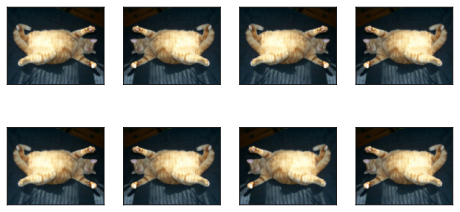

In [17]:
apply(img, torchvision.transforms.RandomHorizontalFlip(), scale=2) 
# 这个是随机的 每次运行的左右方向不一样的 各50%的概率   scale是等比例变大scale倍 或者缩小

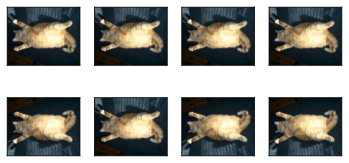

In [14]:
apply(img, torchvision.transforms.RandomVerticalFlip())

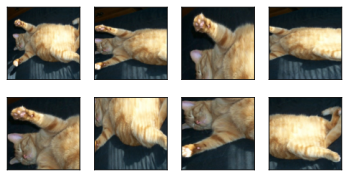

In [18]:
shape_aug = torchvision.transforms.RandomResizedCrop((200,200),scale=(0.1,1),ratio=(0.5,2))
apply(img, shape_aug) 
# scale是随机在0.1~1采样一个值,其代表着占总面积的大小。ratio也是在0.5~2随机采样一个值代表着宽高比。
# （200,200）是resize以后的大小

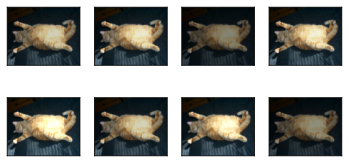

In [19]:
apply(img, torchvision.transforms.ColorJitter(brightness=0.5, contrast=0, saturation=0, hue=0))

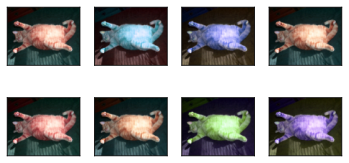

In [20]:
apply(img, torchvision.transforms.ColorJitter(brightness=0, contrast=0, saturation=0, hue=0.5))

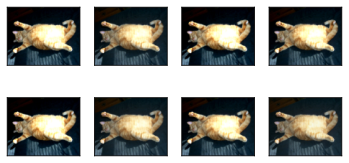

In [21]:
apply(img, torchvision.transforms.ColorJitter(brightness=0, contrast=0.5, saturation=0, hue=0))

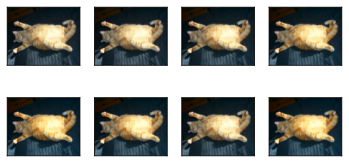

In [22]:
apply(img, torchvision.transforms.ColorJitter(brightness=0, contrast=0, saturation=0.5, hue=0))
# 左至右分别是亮度 对比度 饱和度 色调 0.5代表原值上下0.5随机取值

对比度是图像中明暗区域的差异程度，高对比度图像中明暗区域差异明显，细节清晰；低对比度图像中差异较小，细节模糊。饱和度是色彩的纯度或鲜艳程度，高饱和度图像中色彩鲜艳、丰富；低饱和度图像中色彩暗淡、失真

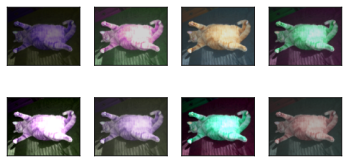

In [23]:
color_aug = torchvision.transforms.ColorJitter(
    brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5)
apply(img, color_aug)

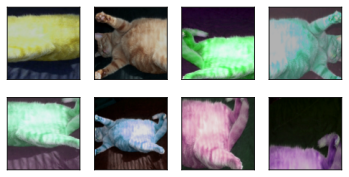

In [24]:
augs =  torchvision.transforms.Compose([torchvision.transforms.RandomHorizontalFlip(),color_aug,shape_aug])
apply(img, augs)

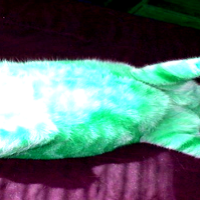

In [25]:
augs(img)

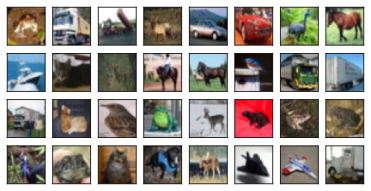

In [39]:
all_images = torchvision.datasets.CIFAR10(root = '../data',download=False,train=True)
d2l.show_images([all_images[i][0] for i in range(32)],4,8,scale = 0.8);

In [76]:
all_images

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ../data
    Split: Train

In [78]:
[*all_images][0:3]  # 所以是先[i][0] 因为1是标签

[(<PIL.Image.Image image mode=RGB size=32x32>, 6),
 (<PIL.Image.Image image mode=RGB size=32x32>, 9),
 (<PIL.Image.Image image mode=RGB size=32x32>, 9)]

In [32]:
x=5,y=8

SyntaxError: cannot assign to literal (289287910.py, line 1)

In [38]:
x=5;y=8
x,y

(5, 8)

In [2]:
train_augs = torchvision.transforms.Compose([torchvision.transforms.RandomHorizontalFlip(),
                                            torchvision.transforms.ToTensor()])

test_augs = torchvision.transforms.Compose(torchvision.transforms.ToTensor())

In [3]:
def load_cifar10(is_train, augs, batch_size):
    dataset = torchvision.datasets.CIFAR10(root='../data', train = is_train, transform = augs, download=True)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,shuffle=is_train, num_workers = d2l.get_dataloader_workers())
    return dataloader
    

In [42]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# 假设我们有一些输入数据 X 和标签 Y
X = torch.randn(100, 3)  # 100个样本，每个样本3个特征
Y = torch.randn(100, 1)  # 100个样本的标签

# 创建 TensorDataset
dataset = TensorDataset(X, Y)

# 创建 DataLoader
dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

# 迭代 DataLoader
for i, (x, y) in enumerate(dataloader):
    print(f"Batch {i}:")
    print(f"Features: {x.size()}, Labels: {y.size()}")
    # 在这里，x 和 y 将是批次的特征和标签


Batch 0:
Features: torch.Size([10, 3]), Labels: torch.Size([10, 1])
Batch 1:
Features: torch.Size([10, 3]), Labels: torch.Size([10, 1])
Batch 2:
Features: torch.Size([10, 3]), Labels: torch.Size([10, 1])
Batch 3:
Features: torch.Size([10, 3]), Labels: torch.Size([10, 1])
Batch 4:
Features: torch.Size([10, 3]), Labels: torch.Size([10, 1])
Batch 5:
Features: torch.Size([10, 3]), Labels: torch.Size([10, 1])
Batch 6:
Features: torch.Size([10, 3]), Labels: torch.Size([10, 1])
Batch 7:
Features: torch.Size([10, 3]), Labels: torch.Size([10, 1])
Batch 8:
Features: torch.Size([10, 3]), Labels: torch.Size([10, 1])
Batch 9:
Features: torch.Size([10, 3]), Labels: torch.Size([10, 1])


In [45]:
[*dataset][:5]  # TensorDataset的作用是用元组把样本数据和标签包起来

[(tensor([-1.0568, -0.2195,  0.4351]), tensor([1.0123])),
 (tensor([-1.0701, -0.7248, -0.5315]), tensor([0.3984])),
 (tensor([0.2483, 0.0672, 1.0512]), tensor([-1.1787])),
 (tensor([ 0.9833, -1.6961,  0.5852]), tensor([0.3166])),
 (tensor([-0.3850, -0.9848,  1.4344]), tensor([-0.5880]))]

In [48]:
[*dataloader][:2]  # 以batchsize为一组,组合在一起

[[tensor([[ 0.2222,  0.1443, -1.7122],
          [-1.0568, -0.2195,  0.4351],
          [ 0.1294,  0.8275, -0.7941],
          [-2.2920, -0.2573,  0.3019],
          [-0.8114,  0.5309, -1.9249],
          [ 0.3796, -0.9763, -2.1350],
          [ 1.5741, -1.6730,  0.4771],
          [-0.2068, -1.8621,  0.8909],
          [-0.5024, -1.2169, -1.0900],
          [ 0.4473,  0.0110, -0.2590]]),
  tensor([[-0.2882],
          [ 1.0123],
          [-1.0156],
          [ 0.3393],
          [-0.3933],
          [-0.0119],
          [-1.5393],
          [-1.7722],
          [-0.9118],
          [-1.0520]])],
 [tensor([[-1.0780, -1.6500,  3.2761],
          [-0.0953, -0.4984, -0.0726],
          [-1.1273, -0.5267,  0.6394],
          [-0.2150, -0.2498, -1.0897],
          [-0.8987, -0.2816, -0.6035],
          [ 0.9833, -1.6961,  0.5852],
          [ 0.3673, -0.4707, -0.2932],
          [-0.4464, -2.1767,  0.3593],
          [ 0.7447,  0.2314, -0.2110],
          [ 0.3227,  2.1278,  1.6598]]),
  t

In [4]:
def train_batch_ch13(net, X, y, loss, trainer, devices):
    if isinstance(X,list):
        X = [x.to(devices[0]) for x in X]
    else:
        X = X.to(devices[0])
    y = y.to(devices[0])
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred,X)
    l.sum().backward()
    trainer.step()
    train_loss_sum = l.sum()
    train_acc_sum = d2l.accuracy(pred, y)
    return train_loss_sum, train_acc_sum

In [5]:
#@save
def train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs,
               devices=d2l.try_all_gpus()):
    """用多GPU进行模型训练"""
    timer, num_batches = d2l.Timer(), len(train_iter)
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0, 1],
                            legend=['train loss', 'train acc', 'test acc'])
    net = nn.DataParallel(net, device_ids=devices).to(devices[0])
    for epoch in range(num_epochs):
        # 4个维度：储存训练损失，训练准确度，实例数，特点数
        metric = d2l.Accumulator(4)
        for i, (features, labels) in enumerate(train_iter):
            timer.start()
            l, acc = train_batch_ch13(
                net, features, labels, loss, trainer, devices)
            metric.add(l, acc, labels.shape[0], labels.numel())
            timer.stop()
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[2], metric[1] / metric[3],
                              None))
        test_acc = d2l.evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {metric[0] / metric[2]:.3f}, train acc '
          f'{metric[1] / metric[3]:.3f}, test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec on '
          f'{str(devices)}')

In [7]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l


class Residual(nn.Module):  #@save
    def __init__(self, input_channels, num_channels,
                 use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels,
                               kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.Conv2d(num_channels, num_channels,
                               kernel_size=3, padding=1)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels,
                                   kernel_size=1, stride=strides)
        else:
            self.conv3 = None
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)



#@save
def resnet18(num_classes, in_channels=1):
    """稍加修改的ResNet-18模型"""
    def resnet_block(in_channels, out_channels, num_residuals,
                     first_block=False):
        blk = []
        for i in range(num_residuals):
            if i == 0 and not first_block:
                blk.append(Residual(in_channels, out_channels,
                                        use_1x1conv=True, strides=2))
            else:
                blk.append(Residual(out_channels, out_channels))
        return nn.Sequential(*blk)

    # 该模型使用了更小的卷积核、步长和填充，而且删除了最大汇聚层
    net = nn.Sequential(
        nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU())
    net.add_module("resnet_block1", resnet_block(
        64, 64, 2, first_block=True))
    net.add_module("resnet_block2", resnet_block(64, 128, 2))
    net.add_module("resnet_block3", resnet_block(128, 256, 2))
    net.add_module("resnet_block4", resnet_block(256, 512, 2))
    net.add_module("global_avg_pool", nn.AdaptiveAvgPool2d((1,1)))
    net.add_module("fc", nn.Sequential(nn.Flatten(),
                                       nn.Linear(512, num_classes)))
    return net

In [8]:
batch_size,devices,net = 256, d2l.try_all_gpus(), resnet18(10,3)
def init_weights(m):
    # if isinstance(m, (nn.Conv2d, nn.Linear)):
    if type(m) in [nn.Conv2d, nn.Linear]:
        nn.init.xavier_normal_(m.weight)
net.apply(init_weights)

def train_with_data_aug(train_augs, test_augs, net, lr=0.001):
    train_iter = load_cifar10(True, train_augs, batch_size)
    test_iter = load_cifar10(False, test_augs, batch_size)
    loss = nn.CrossEntropyLoss(reduction = 'none')
    trainer = torch.optim.Adam(net.parameters(),lr = lr)
    train_ch13(net, train_iter, test_iter, loss, trainer, 10, devices)

In [ ]:
def train_with_data_aug_(train_augs, test_augs, net, lr=0.001):
    train_iter = load_cifar10(True, train_augs, batch_size)
    test_iter = load_cifar10(False, test_augs, batch_size)
    loss = nn.CrossEntropyLoss(reduction = 'none')
    trainer = torch.optim.Adam(net.parameters(),lr = lr)
    d2l.train_ch13(net, train_iter, test_iter, loss, trainer, 10, devices)

train_with_data_aug_(train_augs, test_augs, net, lr=0.001)

Files already downloaded and verified
Files already downloaded and verified


In [56]:
ls = []
isinstance(ls, (nn.Conv2d, list))

True

In [57]:
ls=[1,2,3,4,5]
ls[1:4:2]

[2, 4]

TypeError: Caught TypeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "D:\Pycharm\venv\lib\site-packages\torch\utils\data\_utils\worker.py", line 308, in _worker_loop
    data = fetcher.fetch(index)
  File "D:\Pycharm\venv\lib\site-packages\torch\utils\data\_utils\fetch.py", line 51, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "D:\Pycharm\venv\lib\site-packages\torch\utils\data\_utils\fetch.py", line 51, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "D:\Pycharm\venv\lib\site-packages\torchvision\datasets\cifar.py", line 118, in __getitem__
    img = self.transform(img)
  File "D:\Pycharm\venv\lib\site-packages\torchvision\transforms\transforms.py", line 94, in __call__
    for t in self.transforms:
TypeError: 'ToTensor' object is not iterable


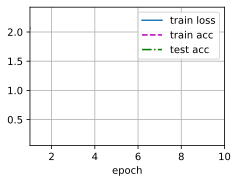

In [12]:
def train_with_data_aug_ch6(train_augs, test_augs, net, lr=0.001):
    train_iter = load_cifar10(True, train_augs, batch_size)
    test_iter = load_cifar10(False, test_augs, batch_size)
    # loss = nn.CrossEntropyLoss(reduction = 'none')
    # trainer = torch.optim.Adam(net.parameters(),lr = lr)
    d2l.train_ch6(net, train_iter, test_iter, 10, lr,devices[0])

train_with_data_aug_ch6(train_augs, test_augs, net, lr=0.001)

In [67]:
d2l.try_all_gpus()[0]

device(type='cuda', index=0)

Files already downloaded and verified
Files already downloaded and verified


RuntimeError: 0D or 1D target tensor expected, multi-target not supported

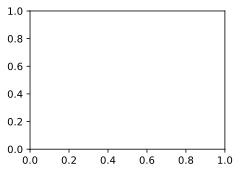

In [9]:
train_with_data_aug(train_augs, test_augs, net)

我单个gpu增广
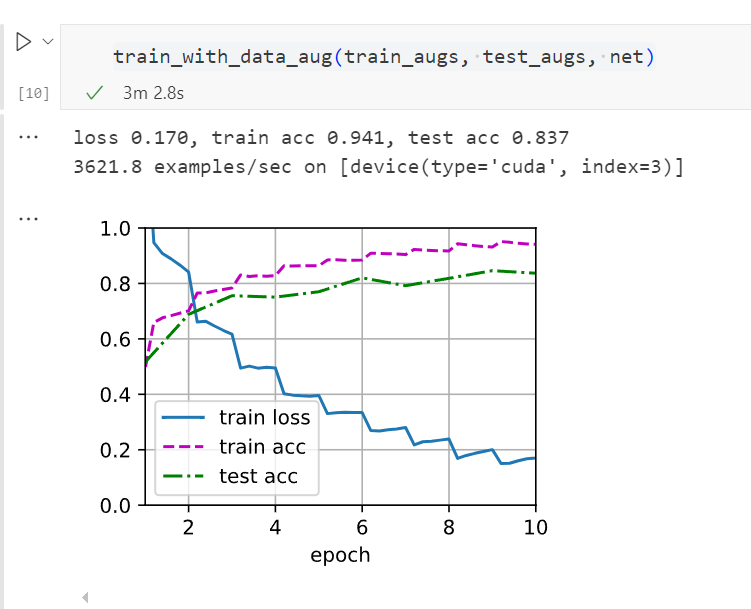

我2个gpu增广
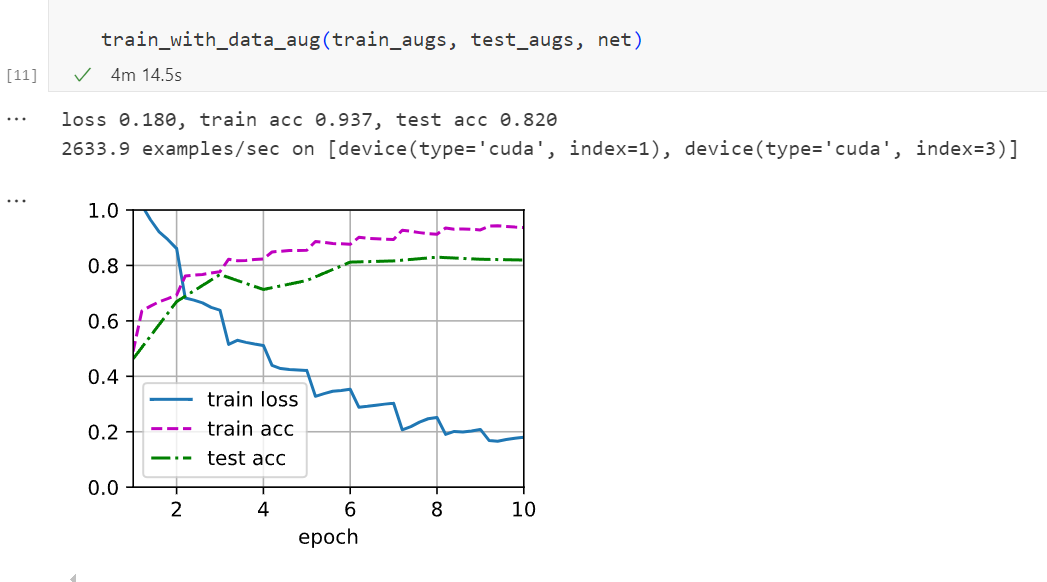

我2个gpu不用增广
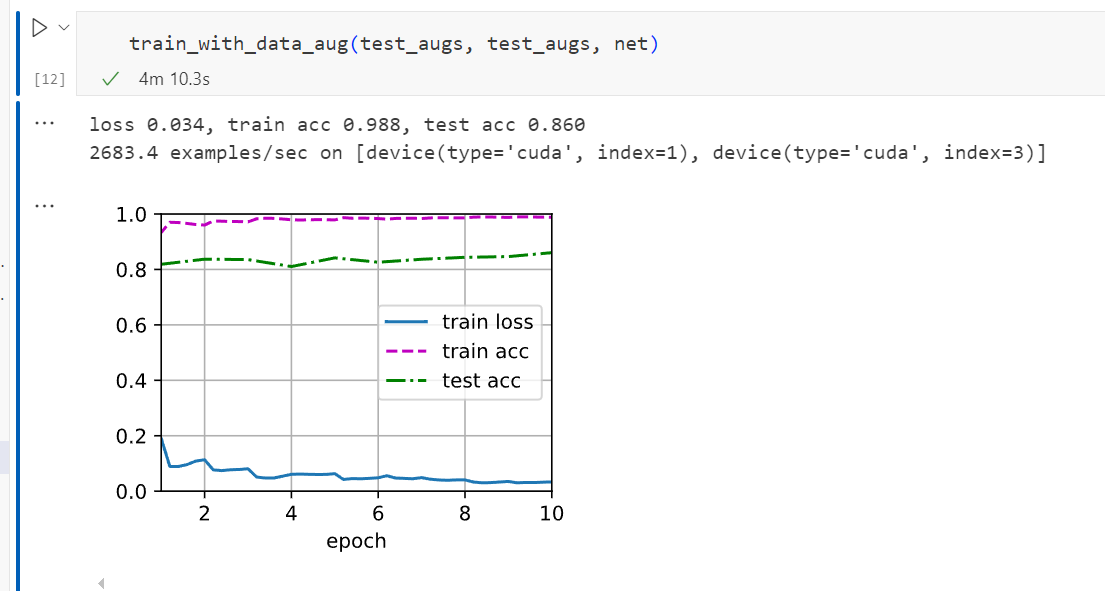
不增广过拟合程度低 难蚌

老师用增广
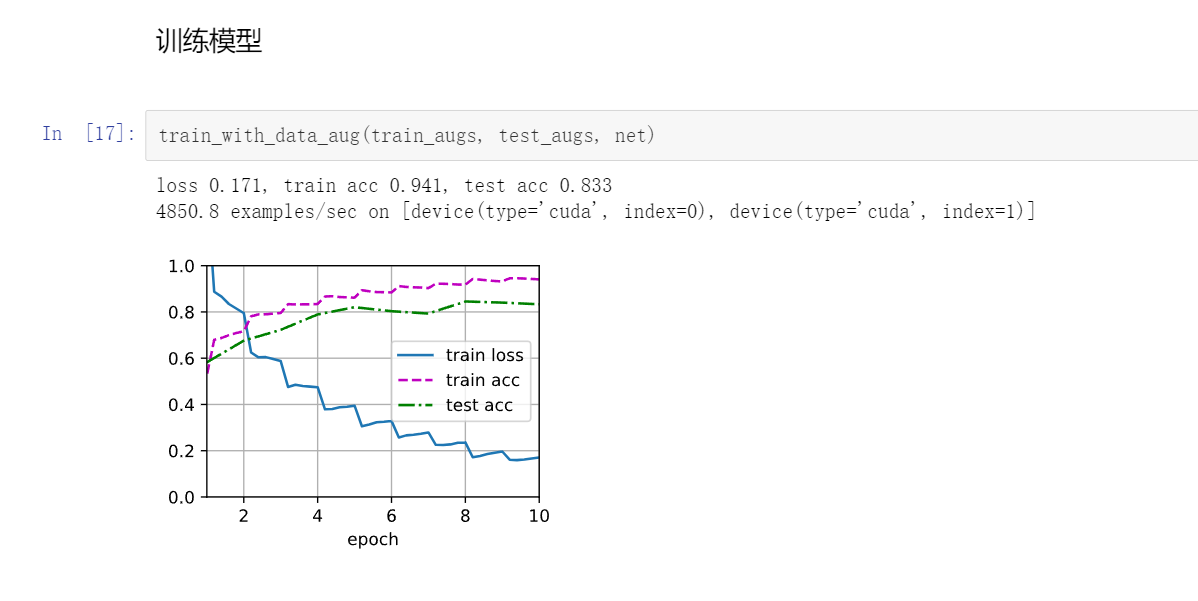

老师不用增广
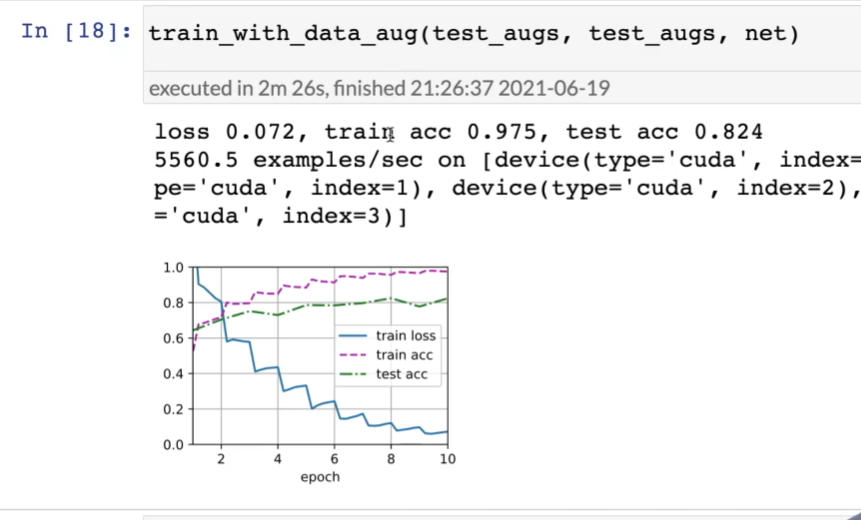

可以看到增广能够起到一定的消除过拟合的效果，甚至有测试精度大于训练精度的可能性，因为训练精度各种变化，比较“奇怪”

## 微调

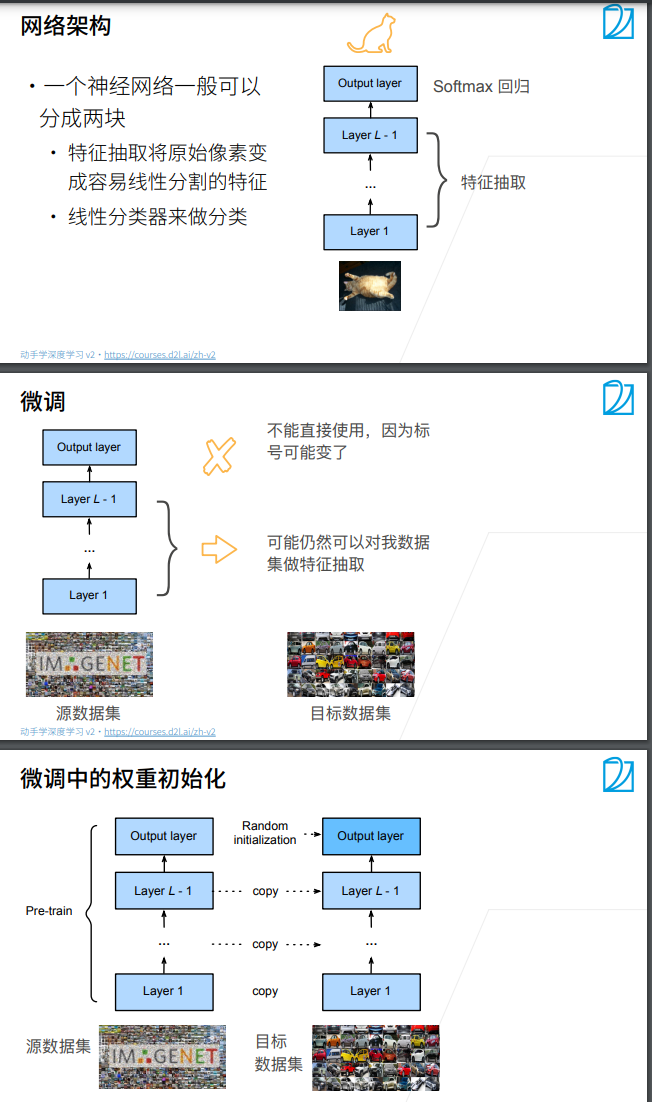
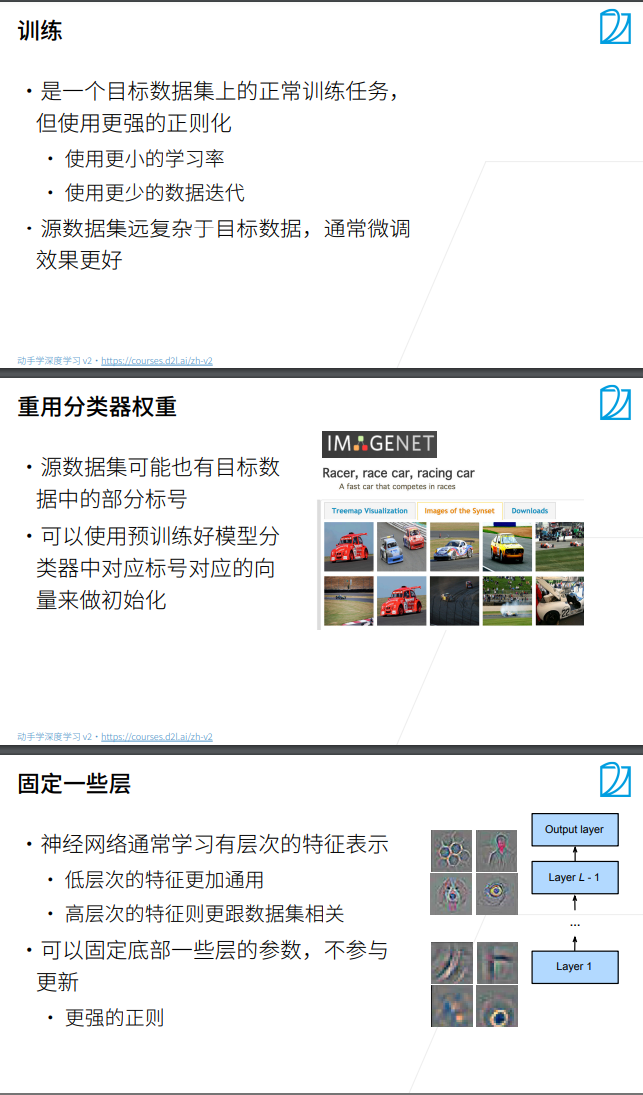

底层的参数可以固定住，因为都是一些通用化的细节。因为是微调，原本就已经做的不错了，所以就只需要较小的学习率，较少的epoch

重用分类器权重，我的理解是向量指的是连接到这个类别的神经元上的各个权重，可以直接原封不动复制过来

In [79]:
%matplotlib inline
import os
import torch
import torchvision
from torch import nn
from d2l import torch as d2l

In [80]:
d2l.DATA_URL

'http://d2l-data.s3-accelerate.amazonaws.com/'

In [81]:
#@save
d2l.DATA_HUB['hotdog'] = (d2l.DATA_URL + 'hotdog.zip',
                         'fba480ffa8aa7e0febbb511d181409f899b9baa5')

data_dir = d2l.download_extract('hotdog')

In [82]:
data_dir

'../data\\hotdog'

In [83]:
train_imgs = torchvision.datasets.ImageFolder(os.path.join(data_dir, 'train'))
test_imgs = torchvision.datasets.ImageFolder(os.path.join(data_dir, 'test'))
# ImageFolder假设所有的文件按文件夹保存，每个文件夹下存储同一个类别的图片，文件夹名为类名


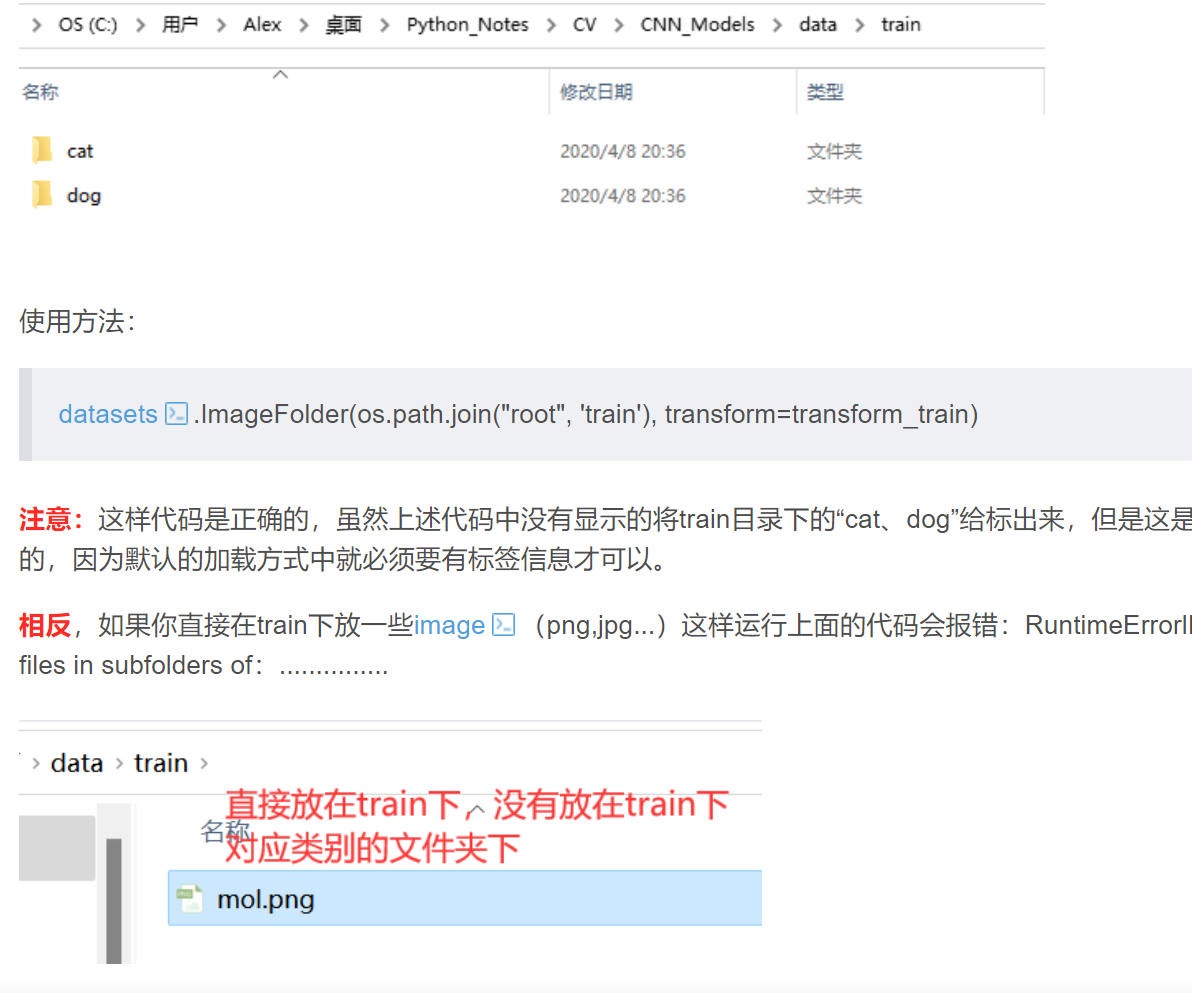

In [84]:
train_imgs  # 一次性全部打包出来

Dataset ImageFolder
    Number of datapoints: 2000
    Root location: ../data\hotdog\train

In [113]:
train_imgs[1888],train_imgs[0]

((<PIL.Image.Image image mode=RGB size=179x163>, 1),
 (<PIL.Image.Image image mode=RGB size=122x144>, 0))

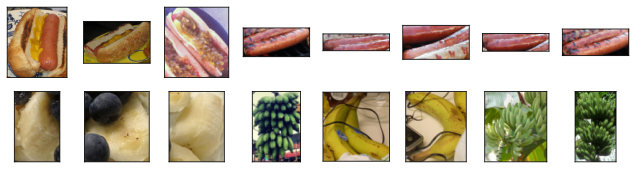

In [85]:
hotdogs = [train_imgs[i][0] for i in range(8)]
not_hotdogs = [train_imgs[-i - 1][0] for i in range(8)]
d2l.show_images(hotdogs + not_hotdogs, 2, 8, scale=1.4);

In [86]:
# 使用RGB通道的均值和标准差，以标准化每个通道
normalize = torchvision.transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) 
# imagenet三个通道的均值和标准差 有没有影响不大 相当于多了一个batchnorm 如果net里面没有bn建议有

train_augs = torchvision.transforms.Compose([torchvision.transforms.RandomResizedCrop(224)
                                            ,torchvision.transforms.RandomHorizontalFlip()
                                            ,torchvision.transforms.ToTensor()
                                            ,normalize]) # 不变成tensor以后再normalize

test_augs = torchvision.transforms.Compose([
                                            torchvision.transforms.Resize([256, 256]),
                                            torchvision.transforms.CenterCrop(224),
                                            torchvision.transforms.ToTensor(),
                                            normalize])

In [88]:
pretrain_net = torchvision.models.resnet18(pretrained = True)

pretrain_net

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [89]:
pretrain_net.fc

Linear(in_features=512, out_features=1000, bias=True)

In [92]:
finetune_net = torchvision.models.resnet18(pretrained = True)
finetune_net.fc = nn.Linear(finetune_net.fc.in_features,2) # 香蕉和热狗 只有2类
nn.init.xavier_uniform_(finetune_net.fc.weight)

Parameter containing:
tensor([[-0.0829, -0.0568, -0.0028,  ..., -0.0507,  0.0992, -0.0179],
        [ 0.0624,  0.0715,  0.0242,  ..., -0.0846, -0.0686,  0.0294]],
       requires_grad=True)

In [93]:
# 如果param_group=True，输出层中的模型参数将使用十倍的学习率
def train_fine_tuning(net, learning_rate, batch_size=128, num_epochs=5,
                      param_group=True):
    train_iter = torch.utils.data.DataLoader(torchvision.datasets.ImageFolder(
        os.path.join(data_dir, 'train'), transform=train_augs),
        batch_size=batch_size, shuffle=True)
    test_iter = torch.utils.data.DataLoader(torchvision.datasets.ImageFolder(
        os.path.join(data_dir, 'test'), transform=test_augs),
        batch_size=batch_size)
    devices = d2l.try_all_gpus()
    loss = nn.CrossEntropyLoss(reduction="none")
    if param_group:
        params_1x = [param for name, param in net.named_parameters()
             if name not in ["fc.weight", "fc.bias"]] # 除了全连接层都放进去的
        trainer = torch.optim.SGD([{'params': params_1x},
                                   {'params': net.fc.parameters(),
                                    'lr': learning_rate * 10}], 
                                  # 最后一层全连接层的学习率10倍,因为只有该层需要重新训练
                                lr=learning_rate, weight_decay=0.001)
    else:
        trainer = torch.optim.SGD(net.parameters(), lr=learning_rate,
                                  weight_decay=0.001)
    d2l.train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs,    # train_ch13没有问题 应该是d2l.resnet18有点问题
                   devices)

loss 0.200, train acc 0.935, test acc 0.902
421.4 examples/sec on [device(type='cuda', index=0)]


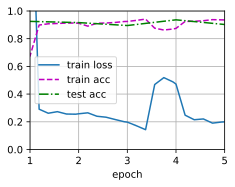

In [94]:
train_fine_tuning(finetune_net, 5e-5)

In [95]:
d2l.try_all_gpus()

[device(type='cuda', index=0)]

In [96]:
nn.DataParallel(finetune_net, d2l.try_all_gpus())

DataParallel(
  (module): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [98]:
net_ = nn.Sequential(nn.Conv2d(3,300,3),nn.BatchNorm2d(300),nn.ReLU(),nn.Linear(300,10))

In [99]:
nn.DataParallel(net_, d2l.try_all_gpus())

DataParallel(
  (module): Sequential(
    (0): Conv2d(3, 300, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=10, bias=True)
  )
)

In [108]:
net_

Sequential(
  (0): Conv2d(3, 300, kernel_size=(3, 3), stride=(1, 1))
  (1): BatchNorm2d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Linear(in_features=300, out_features=10, bias=True)
)

loss 0.371, train acc 0.840, test acc 0.850
421.3 examples/sec on [device(type='cuda', index=0)]


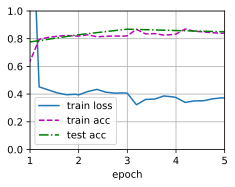

In [109]:
scratch_net = torchvision.models.resnet18()
scratch_net.fc = nn.Linear(scratch_net.fc.in_features, 2)  
train_fine_tuning(scratch_net, 5e-4, param_group=False)

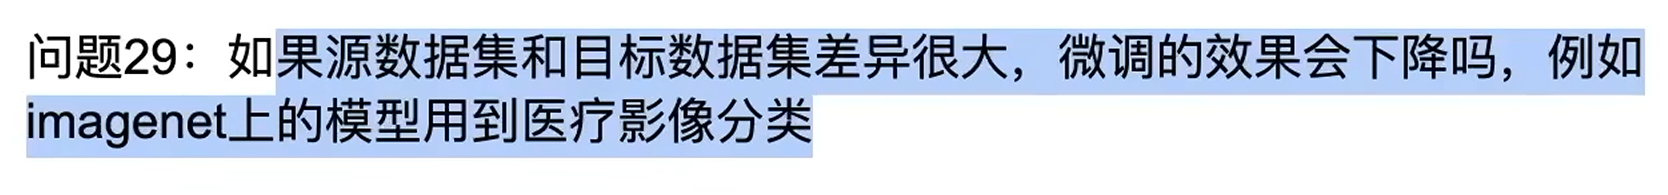
类似就可以了 不需要完全一样。但差异很大不推荐，泪如这个例子里面，最好是医学里pretrain过的